<a href="https://colab.research.google.com/github/Laura-Filkova/CB2330-KICKASS-PROJECT/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROJECT CARD**

**DATA LOADING AND PREPROCESSING**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.special import digamma

In [5]:
s3_a_df = pd.read_excel('/content/science.adq8381_table_s3.xlsx','Table S3A')
s3_b_df = pd.read_excel('/content/science.adq8381_table_s3.xlsx','Table S3B')

s3_a_df.sample(3)

,UniProt ID,name,IDR start,IDR end,IDR len,number of psites,pre-post,epsilon_pre,epsilon_post,sequence_pre,sequence_post
8185,Q9H161,sp|Q9H161|ALX4_HUMAN Homeobox protein aristal...,296,411,116,2,-1.55,6.18,7.73,RAENYAQIQNPSWLGNNGAASPVPACVVPCDPVPACMSPHAHPPG...,RAENYAQIQNPSWLGNNGAASPVPACVVPCDPVPACMSPHAHPPG...
12544,Q8N554,sp|Q8N554|ZN276_HUMAN Zinc finger protein 276...,1,109,109,6,-4.03,-2.51,1.52,MKRDRLGRFLSPGSSRQCGASDGGGGVSRTRGRPSLSGGPRVDGA...,MKRDRLGRFLEPGSSRQCGAEDGGGGVERTRGRPELSGGPRVDGA...
7539,Q9C0F3,sp|Q9C0F3|ZN436_HUMAN Zinc finger protein 436...,1,125,125,1,-1.30,19.60,20.90,MAATLLMAGSQAPVTFEDMAMYLTREEWRPLDAAQRDLYRDVMQE...,MAATLLMAGEQAPVTFEDMAMYLTREEWRPLDAAQRDLYRDVMQE...


In [6]:
# Strip leading/trailing whitespaces from column names to prevent KeyError
s3_a_df.columns = s3_a_df.columns.str.strip()
s3_b_df.columns = s3_b_df.columns.str.strip()

def count_idr_psites(row):
    seq_pre = str(row['sequence_pre'])
    seq_post = str(row['sequence_post'])
    # Count differences between pre and post sequences
    return sum(1 for a, b in zip(seq_pre, seq_post) if a != b)

# Calculate for s3_a_df and s3_b_df
s3_a_df['idr_psites'] = s3_a_df.apply(count_idr_psites, axis=1)
s3_b_df['idr_psites'] = s3_b_df.apply(count_idr_psites, axis=1)

# Display sample to verify
s3_a_df[['UniProt ID', 'IDR start', 'IDR end', 'IDR len', 'number of psites', 'idr_psites']].head()

,UniProt ID,IDR start,IDR end,IDR len,number of psites,idr_psites
0,Q5BKY9,78,247,170,30,27
1,P10412,92,219,128,50,10
2,P16401,95,226,132,37,10
3,Q8N9Q2,41,155,115,16,16
4,P07305,84,194,111,17,8


**DATA VISUALIZATION**

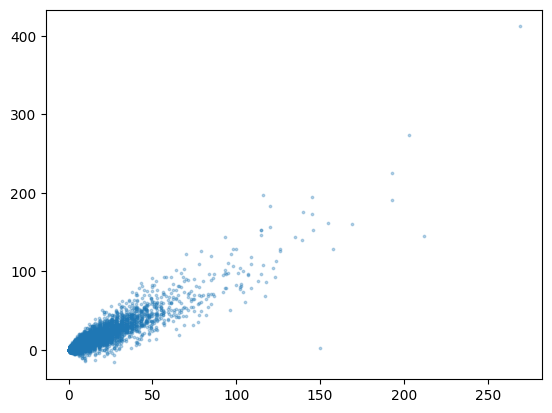

In [7]:
plt.scatter(
    s3_a_df['idr_psites'],
    -s3_a_df['pre-post'],
    s=3,
    alpha=0.3)
plt.show()

**BASE FUNCTIONS**

In [30]:
def nll(a, sigma, df = s3_a_df):
  total = 0
  N = len(df)
  for i in range(N):
    xi = df['idr_psites'][i]
    yi = -df['pre-post'][i]
    total += ((a* xi - yi)/sigma)**2*0.5
  if sigma <= 0:
    return float('inf')
  return total + math.log(sigma*math.sqrt(2*math.pi)) * N

def linear(x, a):
  return x * a

def show_fitted_line(a, df = s3_a_df, func = linear):
  min_sites = df['idr_psites'].min()
  max_sites = df['idr_psites'].max()

  x_line = np.linspace( min_sites, max_sites, 300 )
  y_line = func(x_line,a)
  plt.figure(figsize=(10, 6))
  plt.scatter(
      df['idr_psites'],
      -df['pre-post'],
      s=3,
      alpha=0.3,
  )


  num_bins = 50

  bins = np.linspace(min_sites, max_sites, num_bins + 1)
  df_copy = df.copy()
  df_copy['sites_bin'] = pd.cut(df_copy['idr_psites'], bins=bins, include_lowest=True)

  grouped = df_copy.groupby('sites_bin')['pre-post'].mean().reset_index()
  bin_midpoints = [(interval.left + interval.right) / 2 for interval in grouped['sites_bin']]
  plt.plot(bin_midpoints, -grouped['pre-post'], color='blue', linewidth=2, label='Mean of -pre-post in bins'
  )

  plt.plot(x_line, y_line, color='red', linewidth=2, label='Fitted model'
  )

  plt.xlim(0.0, 150)
  plt.ylim(0.0,150)
  plt.xlabel('Number of psites')
  plt.ylabel('Post-Pre')
  plt.title(' Pre-Post vs. Number of psites with average and fitted curve'
  )
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()



**FORWARD SIMULATION**

**FITTING**

In [11]:
def fit(alpha = 0.001, df = s3_a_df):
  a,sigma = 1,1
  CYCLES = 1000
  N = len(df)
  for c in range(CYCLES):
    if c % 50 == 0:
      print(f'Cycle {c}')
    a_der = 0
    sigma_der = N/sigma
    for i in range(N):
      yi = -df['pre-post'][i]
      xi = df['idr_psites'][i]
      mui = (a*xi)

      a_der += xi*(mui - yi)/sigma**2
      sigma_der -= (mui - yi)**2 / sigma**3
    a_new = a - alpha*a_der
    sigma_new = sigma - alpha*sigma_der

    new_nll = nll(a_new, sigma_new, df)
    current_nll = nll(a, sigma, df)
    if new_nll < current_nll:
        a, sigma = a_new, sigma_new
        alpha = alpha * 1.2
    else:
        alpha = alpha * 0.5
  return a,sigma


In [12]:
a, sigma = fit()

Cycle 0
Cycle 50
Cycle 100
Cycle 150
Cycle 200
Cycle 250
Cycle 300
Cycle 350
Cycle 400
Cycle 450
Cycle 500
Cycle 550
Cycle 600
Cycle 650
Cycle 700
Cycle 750
Cycle 800
Cycle 850
Cycle 900
Cycle 950


/tmp/ipykernel_632/1453471498.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_copy.groupby('sites_bin')['pre-post'].mean().reset_index()


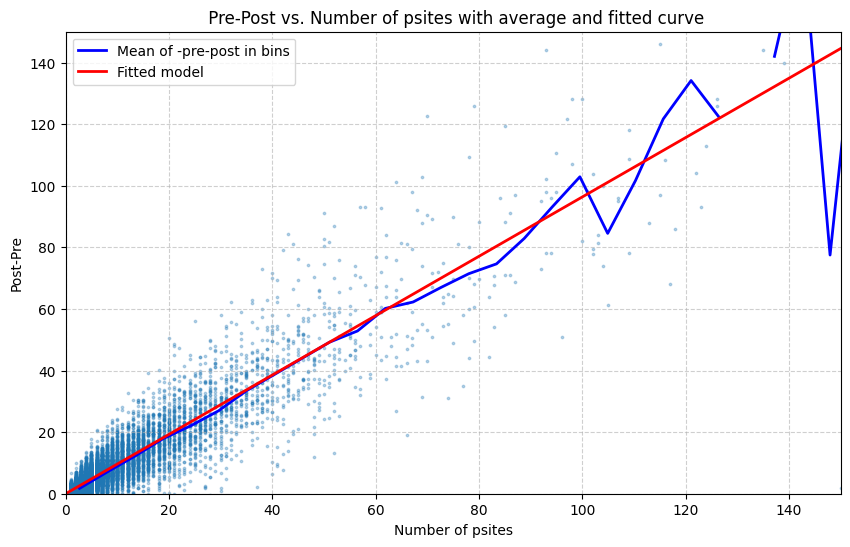

In [31]:
show_fitted_line(a)

**BOOTSTRAPPING**